In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import pingouin as pg

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype']=42
%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif'] 

def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple' ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

%load_ext autoreload
%autoreload 2

import scipy.signal as sg
sns.set_context("poster")
sns.set_style("ticks")

C:\Users\AChub_Lab\anaconda3\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [3]:
# Stage 3 training files
filedir=r'U:\Data\snareddu\v1_gamma_inh_of_behav\Stage3'
frrwdfiles=glob.glob(filedir+'\day*\*.csv')
frrwdfiles

['U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_464-et01.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_465-et161.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-PJJ0GDK_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_467-et315.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_421-et317.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_422-et316.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 1\\WINDOWS-RI84KQQ_ketamine_Stage 3 Pink noise discrimination_oneatatimevideo_v4_476-et0.csv',
 'U:\\Data\\snareddu\\v1_gamma_inh_of_behav\\Stage3\\Day 10\\WINDOWS-PJJ0GDK_ke

In [17]:
dfls=[]
for f in frrwdfiles:
    infodf=pd.read_csv(f,names=['Name','Value',''],skiprows=np.arange(17,10000*2,1))
    day=int(f.split('\\')[-2][3:])
    #print(day,f)
    et=f.split('_')[-1].split('.')[0].split('-')[-1][-3:]
    
    tmpdf=pd.read_csv(f,skiprows=17)
    if 'Evnt_Time' not in tmpdf.columns:
        tmpdf=pd.read_csv(f,skiprows=17,header=1)
#     et=f.split('_')[-2]
#     break

    startcorr=tmpdf[(tmpdf.Group_ID==2)
                 &(tmpdf.Item_Name.str.contains('correction'))
                 ].Evnt_Time.values

    dispmov1t=tmpdf[(tmpdf.Group_ID==3)
                   &(tmpdf.Evnt_Name.str.contains('Play Video')) 
                   &(tmpdf.Arg2_Name=='Video 1')
                   ].Evnt_Time.values
    dispmov2t=tmpdf[(tmpdf.Group_ID==3)
                    &(tmpdf.Evnt_Name.str.contains('Play Video'))
                    &(tmpdf.Arg2_Name=='Video 2')
                   ].Evnt_Time.values
    mov1cortoucht=tmpdf[(tmpdf.Group_ID==4)
                        &(tmpdf.Item_Name=='loccorrecttouch')
                       ].Evnt_Time.values
    mov2notoucht=tmpdf[(tmpdf.Group_ID==4)
                        &(tmpdf.Item_Name=='corrnotouch')
                       ].Evnt_Time.values
    mov1notoucht=tmpdf[(tmpdf.Group_ID==4)
                        &(tmpdf.Item_Name=='notouch')
                       ].Evnt_Time.values
    mov2inctoucht=tmpdf[(tmpdf.Group_ID==4)
                        &(tmpdf.Item_Name=='locinctouch')
                       ].Evnt_Time.values
    mov2notouchcorrectiont=tmpdf[(tmpdf.Group_ID==4)
                                &(tmpdf.Item_Name=='locinctouchcorrection')
                               ].Evnt_Time.values
    mov1touchcorrectiont=tmpdf[(tmpdf.Group_ID==4)
                              &(tmpdf.Item_Name=='loccorrecttouchcorrection')
                              ].Evnt_Time.values
    trayentryt=tmpdf[(tmpdf.Group_ID==12)
                     &(tmpdf.Evnt_Name.str.contains('On Event'))
                    ].Evnt_Time.values

    onesessionls=[]
    alldispt=sorted(np.hstack([dispmov1t,dispmov2t]))
    alldispt.append(tmpdf.Evnt_Time.max())
    for i,t0 in enumerate(alldispt[:-1]):
        CorrT=0 # Correct response=0, incorrect response=1
        t0,t1=alldispt[i],alldispt[i+1]
        if t0 in dispmov1t:
            stim=1 #go stimulus
        else:
            stim=2 #nogo stimulus
        if stim==1:
            t_movtoucht=mov1cortoucht[(mov1cortoucht>t0)&(mov1cortoucht<t1)]
            t_movnotoucht=mov1notoucht[(mov1notoucht>t0)&(mov1notoucht<t1)]
            t_movcorrrectiont=mov1touchcorrectiont[(mov1touchcorrectiont>t0)&(mov1touchcorrectiont<t1)]
            t_trayentryt=trayentryt[(trayentryt>t0)&(trayentryt<t1)]
            if t_movnotoucht.shape[0]:
                CorrT=1
        elif stim==2:
            t_movnotoucht=mov2notoucht[(mov2notoucht>t0)&(mov2notoucht<t1)]
            t_movtoucht=mov2inctoucht[(mov2inctoucht>t0)&(mov2inctoucht<t1)]
            t_movcorrrectiont=mov2notouchcorrectiont[(mov2notouchcorrectiont>t0)&(mov2notouchcorrectiont<t1)]
            if t_movtoucht.shape[0]:
                CorrT=1
        if t_movcorrrectiont.shape[0]:
            CorrT=1
        if i>=1:
            start_corr_t=startcorr[(startcorr<t0)&(startcorr>alldispt[i-1])]

        if t_movtoucht.shape[0] or t_movcorrrectiont.shape[0]:
            disp2touch=min(np.hstack([t_movtoucht,t_movcorrrectiont])-t0)
            if stim==1 and len(t_trayentryt):
                touch2entry=min(t_trayentryt-t_movtoucht)
            else:
                touch2entry=np.nan
        if t_movnotoucht.shape[0]:
            disp2touch=np.nan
            touch2entry=np.nan

        onesessionls.append((i,stim,disp2touch,touch2entry,np.nan, CorrT))

    onesessiondf=pd.DataFrame(onesessionls,columns=['trial','stim','disp2touch','touch2entry','laser', 'CorrT'])
    onesessiondf['et']=et
    onesessiondf['day']=day
    dfls.append(onesessiondf)
    
allsessiondf=pd.concat(dfls)
allsessiondf[allsessiondf['stim']==1].tail()

,trial,stim,disp2touch,touch2entry,laser,CorrT,et,day
244,244,1,4.212,NaN,NaN,1,316,9
245,245,1,1.986,3.692,NaN,0,316,9
247,247,1,NaN,NaN,NaN,1,316,9
248,248,1,0.705,8.447,NaN,0,316,9
258,258,1,0.015,4.583,NaN,0,316,9


In [18]:
tmp_foo=allsessiondf 
perc_correct=tmp_foo[(tmp_foo.stim.isin([1,2,3]))
                         ].groupby(['et','stim','day']
                                  ).apply(lambda x:x[(x.CorrT==0)&(x.trial.isin(x.trial.unique()[:]))
                                                    ].disp2touch.shape[0]/x[x.trial.isin(x.trial.unique()[:])
                                                                          ].disp2touch.shape[0]
                                             ).to_frame('perc_correct').reset_index()


### adding perc_touches to df
ls1=[]
for a,b, in perc_correct.groupby(['et','stim','day']):

    if a[1]==2:
        ls=b.apply(lambda x:1-x.perc_correct,axis=1)
        ls1.append(ls)
    else:
        ls=b.apply(lambda x:x.perc_correct,axis=1)
        ls1.append(ls)        
            
ls_ar=np.array(ls1)
perc_correct['perc_tch']=ls_ar

perc_correct

,et,stim,day,perc_correct,perc_tch
0,161,1,1,0.130037,0.130037
1,161,1,2,0.151709,0.151709
2,161,1,3,0.190860,0.190860
3,161,1,4,0.015402,0.015402
4,161,1,5,0.063549,0.063549
...,...,...,...,...,...
351,t01,2,27,0.686047,0.313953
352,t01,2,28,0.415493,0.584507
353,t01,2,29,0.464567,0.535433
354,t01,2,30,0.670455,0.329545


In [19]:
#### Getting TS scores ####

import scipy.stats as sstat
ZZ = sstat.norm.ppf

all_ts_df=[]

for d, dd in perc_correct.groupby(['day']):
    for e, ee in dd.groupby(['et']):
            HR=ee[ee.stim==1]['perc_tch'].values
#             print(HR)
            if HR>=1:
                HR=0.99999
            elif HR==0:
                HR=0.00001
            FA=ee[ee.stim==2]['perc_tch'].values
#             print(FA)
            if FA>=1:
                FA=0.99999
            elif FA==0:
                FA=0.00001
            TS = ZZ(HR)-ZZ(FA)
            
            ts_tmp=pd.DataFrame({ 
                                 'day': [d],
                                 'et' : [e],
                                 'HR' : HR,
                                 'FA' : FA,
                                 'TS' : TS
                                })
            all_ts_df.append(ts_tmp)
            
all_ts_df = pd.concat(all_ts_df,ignore_index=True)
all_ts_df.head()


,day,et,HR,FA,TS
0,1,161,0.130037,0.385417,-0.834933
1,1,315,0.064039,0.192308,-0.652298
2,1,316,0.213855,0.378947,-0.484868
3,1,317,0.185379,0.453704,-0.778747
4,1,et0,0.092105,0.301370,-0.807437


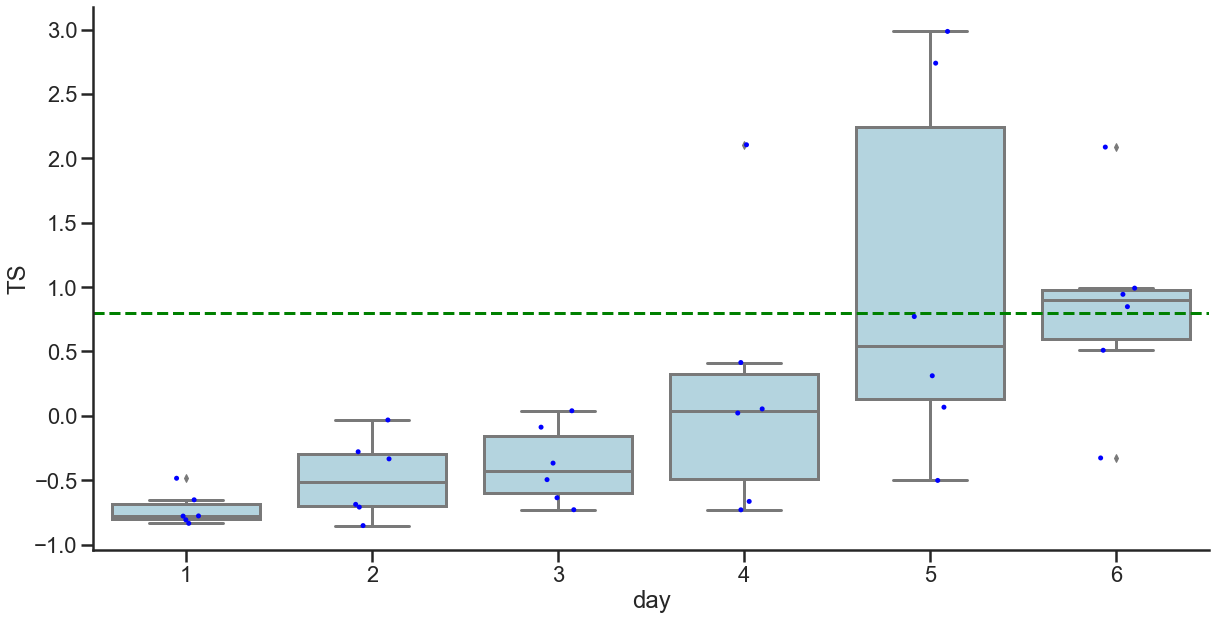

In [20]:
## Plotting TS values ## 

f,ax=plt.subplots(1,1,figsize=(20, 10))

sns.boxplot(data=all_ts_df[all_ts_df.day<7],  x='day', y='TS',
            palette={'lightblue'},
            ax=ax)

sns.stripplot(data=all_ts_df[all_ts_df.day<7],  x='day', y='TS',
            dodge = True,
            palette={'blue'}, ax=ax)

ax.legend('',frameon=False)
sns.despine()
plt.axhline( y=0.8, ls='--', c='green')

plt.show()